### Decision Tree Classifier 

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV,GridSearchCV
from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay



In [ ]:
##Data to be used
data = pd.read_csv('forModel.csv')
data.drop(['Checkup','Unnamed: 0.1','Unnamed: 0'], axis = 1, inplace =True)

##Cloned Data 
clonedData = pd.read_csv('forModel.csv')
clonedData['Heart_Disease'] = clonedData['Heart_Disease'].map({'Yes':1,'No':0})
data.head(5)

data['General_Health'] = data['General_Health'].apply(lambda x: 'Poor' if x == 'Poor' else 'Good')
data['General_Health'] = data['General_Health'].map({"Poor":1, "Good":0})
data['Sex'] = data['Sex'].map({'Male':1, 'Female':0})
data['Diabetes'] = data['Diabetes'].apply(lambda x:'No' if x == 'No' else 'Yes')
## Since most of the Binary have Yes and No we will convert all of them at once 
cols = ['Exercise','Heart_Disease','Skin_Cancer','Other_Cancer','Depression','Arthritis','Smoking_History','Diabetes']
for each in cols:
    data[each] = data[each].map({'Yes':1,'No':0}) ##This converts the whole data into the binary 

dummied_data = pd.get_dummies(data, columns=['Age_Category'], dtype = 'int')


X = dummied_data.drop(columns = 'Heart_Disease', axis = 1)
y = dummied_data['Heart_Disease']
X_train, X_test, y_train , y_test = train_test_split(X,y , test_size= 0.2, random_state= 52)




### Lets evaluate the decision tree classifier and then lets see how does it work 

Training Accuracy: 0.9999453125
testing_accuracy: 0.894625
Precision: 0.8477635075287865
Recall: 0.960968875502008
0.8949138557310667


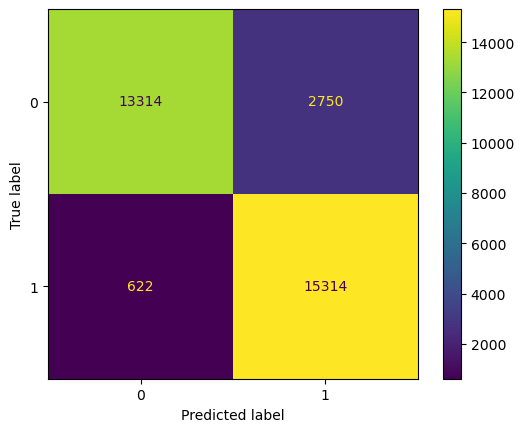

In [ ]:
## Base model of the Decision Tree Classifier without hyper tuned
model = DecisionTreeClassifier(
    # max_depth = 5,
    # max_features = 'sqrt',
    # min_samples_split = 10,
    # min_samples_leaf = 5
)
model.fit(X_train,y_train)

training_pred = model.predict(X_train)
testing_pred = model.predict(X_test)
training_prob = model.predict_proba(X_train)[:,1]
testing_prob = model.predict_proba(X_test)[:,1]


## Testing the metrics of the base model 
training_accuracy = accuracy_score(y_train, training_pred)
testing_accuracy = accuracy_score(y_test, testing_pred)
print("Training Accuracy:", training_accuracy)
print("testing_accuracy:", testing_accuracy)
## Precision, recall and f1-score
precision = precision_score(y_test, testing_pred)
print("Precision:", precision)
recall = recall_score(y_test, testing_pred)
print("Recall:", recall)
## Confusion matrix 
evaluation_matrix = confusion_matrix(y_test, testing_pred)
display = ConfusionMatrixDisplay(confusion_matrix=evaluation_matrix)
display.plot()

## Roc_Auc Score
fpr, tpr, threshold = roc_curve(y_test, testing_prob)
roc_score= roc_auc_score(y_test, testing_prob)





In [ ]:
decision_model = DecisionTreeClassifier(criterion='gini', random_state = 52)

## Checking the number of features and the number of samples
# The data set has 160000 number of samples and 19 number of features, and the ratio of the features to samples is given by 0.00011875

## So we will be considering the total samples in the leaf node to be 0.1% of the total samples : 160 

hyper_parametrs = {
    'max_depth':[8,9,10,11,12],
    'min_samples_split':[350,400,450,500],
    'min_samples_leaf':[120,150,160,170],
    'max_features':['sqrt',None, 0.1,0.2]
}

## To preserve the class imbalance 
kf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42 )

## Lets Imply the Randomized Search Cv 
hyper_tuned = GridSearchCV(decision_model, param_grid=hyper_parametrs, cv = kf, n_jobs =-1) 

hyper_tuned.fit(X_train,y_train)

best_model = hyper_tuned.best_estimator_




Training Accuracy: 0.7488515625
testing_accuracy: 0.7416875
Precision: 0.7171820138180994
Recall: 0.7946787148594378


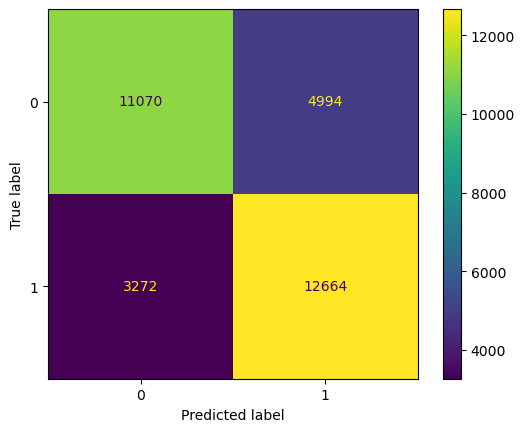

In [ ]:
best_features = hyper_tuned.best_params_
best_model_features = best_model.feature_importances_

best_features_used = pd.DataFrame({
    'features':X.columns,
    'Feature_score':best_model_features
})

best_features_used= best_features_used.sort_values(by='Feature_score', ascending=False)
best_features_used.head(5)

training_pred = best_model.predict(X_train)
testing_pred = best_model.predict(X_test)
training_prob = best_model.predict_proba(X_train)[:,1]
testing_prob = best_model.predict_proba(X_test)[:,1]


## Testing the metrics of the base model 
training_accuracy = accuracy_score(y_train, training_pred)
testing_accuracy = accuracy_score(y_test, testing_pred)
print("Training Accuracy:", training_accuracy)
print("testing_accuracy:", testing_accuracy)
## Precision, recall and f1-score
hypertuned_precision = precision_score(y_test, testing_pred)
print("Precision:", hypertuned_precision)
hypertuned_recall = recall_score(y_test, testing_pred)
print("Recall:", hypertuned_recall)

## Roc_Auc Metrics
fpr_thres, tpr_thres, thresholds = roc_curve(y_test, testing_prob)
roc_score_thres= roc_auc_score(y_test, testing_prob)


## Confusion matrix 
evaluation_matrix = confusion_matrix(y_test, testing_pred)
display = ConfusionMatrixDisplay(confusion_matrix=evaluation_matrix)
display.plot()


---
### Increasing the Recall 

In [ ]:
### here we will be trying to decrease the false negatives and increase recall because as we are predicting the chance of having a heart disease we cannot ignore the false negatives which means missing out the cases where a patient can be a heart patient. For that we will be doing threshold tuning.

## To increase the recall we need to make sure that the model has lower threshold 
## Lets see the threshold from which we can get the maximum recall

precision, recall, thresholds = precision_recall_curve(y_test, testing_prob)
index = recall.argmax()
required_threshold = thresholds[index] ## So to get the maximum recall we need the threshold of 0.05

# We will be testing the precision, recall, false_positives and negatives through a range of thresholds which will make sure we are not increasing the number of false positives rapidly and also making sure that the number of false negatives are also decreased.


thresholds_checked = [0.05, 0.1,0.2,0.25,0.3,0.32,0.35,0.4]
training_accuracies = []
testing_accuracies = []
precision_stored = []
recall_stored = []
f1_score_stored = []


for threshold in thresholds_checked:
    threshold_training_pred = (training_prob >= threshold).astype(int)
    threshold_testing_pred = (testing_prob >= threshold).astype(int)

    ## Precision calculated 

    precision = precision_score(y_test, threshold_testing_pred)
    precision_stored.append(precision)

    recall = recall_score(y_test, threshold_testing_pred)
    recall_stored.append(recall)

    f1_value = f1_score(y_test, threshold_testing_pred)
    f1_score_stored.append(f1_value)

    ## Training and Testing Accuracies

    training_accuracy = accuracy_score(y_train, threshold_training_pred)
    training_accuracies.append(training_accuracy)
    testing_accuracy = accuracy_score(y_test, threshold_testing_pred)
    testing_accuracies.append(testing_accuracy)


## DataFrame of the values 
data = pd.DataFrame({
    'threshold_used': thresholds_checked,
    'training_accuracy': training_accuracies,
    'testing_accuracy': testing_accuracy,
    'precision':precision_stored,
    'recall': recall_stored,
    'f1_score':f1_score_stored
})




data.head(6)


,threshold_used,training_accuracy,testing_accuracy,precision,recall,f1_score
0,0.05,0.500500,0.733437,0.498000,1.000000,0.664887
1,0.10,0.603633,0.733437,0.555230,0.985693,0.710335
2,0.20,0.686352,0.733437,0.615369,0.953251,0.747920
3,0.25,0.708883,0.733437,0.637125,0.935617,0.758046
4,0.30,0.715508,0.733437,0.643713,0.926832,0.759754
5,0.32,0.725102,0.733437,0.655962,0.910015,0.762380


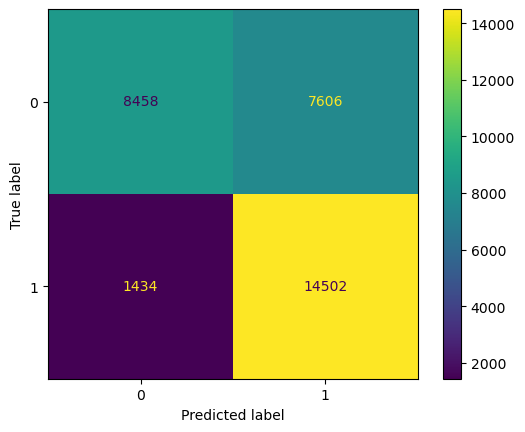

In [ ]:
## As we can see from the table if we take the threshold of 0.35 then the model can detect the cardio vascular cases 89% of times whereas the precison of the model drops from 0.71 to 0.66

## Lets evaluate the false positives and false negatives value from the confusion matrix with the threshold of 0.25 

threshold_training = (training_prob >= 0.32).astype(int)
threshold_testing = (testing_prob >= 0.32).astype(int)

evaluation_matrix = confusion_matrix(y_test, threshold_testing)
display = ConfusionMatrixDisplay(confusion_matrix=evaluation_matrix)
display.plot()

### The new recall score is 91% with just False Negatives dropping by 1838 patients. This way we can make sure that our model catches most of the True Negatives which is one of the most prominent category while diagnosing the patient with heart disease

---

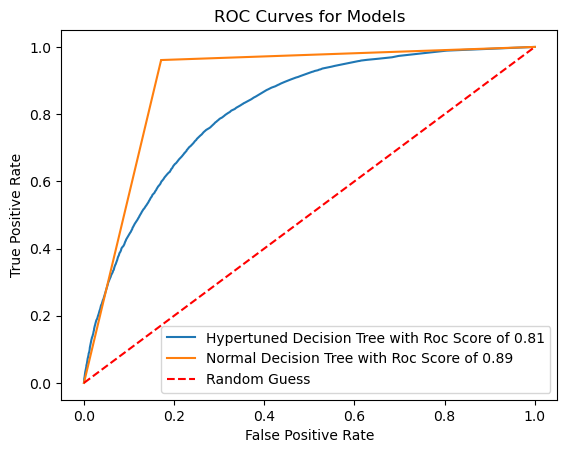

In [ ]:
### Lets compare the ROC-AUC of the two models and see how does our hyper tuned model do in distinguishing the difference in the positive and negative case 


plt.plot(fpr_thres,tpr_thres, label = f'Hypertuned Decision Tree with Roc Score of {roc_score_thres:.2f}')
plt.plot(fpr,tpr, label = f'Normal Decision Tree with Roc Score of {roc_score:.2f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Models')
plt.legend()
plt.legend()
plt.show()

### Since missing disease cannot be acceptable especially in the medical field, I decide to go with the model with the recall scoer of 92% 